In [1]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import Akima1DInterpolator
from PIL import Image
from glob import glob
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom

NOTEBOOK_NAME = "explore_data.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home   = os.path.join(self.rws, "src")
        self.images = os.path.normpath(os.path.join(self.home, '../images'))
        self.data   = os.path.normpath(os.path.join(self.home, '../data'))
        self.pb_data = os.path.normpath(os.path.join(self.data, 'peilbuizen'))
        self.pb_imag = os.path.normpath(os.path.join(self.images, 'peilbuizen'))
        
dirs = Dirs()

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

print("Project directory namespace:")
descr(dirs)

loading mfpath.py
NOTEBOOK_NAME = 'explore_data.ipynb'
Project directory namespace:
rws                  /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/
home                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src
images               /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images
data                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data
pb_data              /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/data/peilbuizen
pb_imag              /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/peilbuizen


In [11]:
class Peilbuizen():
    def __init__(self, workbook_name, sheet_name=None):
        self.data = pd.read_excel(os.path.join(dirs.pb_imag, workbook_name), sheet_name=sheet_name, index_col='name')
        
    def plot(self, ax, **kwargs):
        """Plot all observation well locations at once."""
        ax.plot(self.data['x'], self.data['y'], 'o', **kwargs)
        
    def put_raai_names(self, ax, xoffset=100., verbose=False, **kwargs):
        """Put the piezometer row names to the right of the last in the row + xoffset."""
        rows = np.arange(100, 1500, 100)
        for r1, r2 in zip(rows[:-1], rows[1:]):
            y = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'y'].mean().round()
            x = pbxy.data.loc[np.logical_and(pbxy.data.index >= r1, pbxy.data.index < r2), 'x'].values[-1].round() + xoffset
            ax.text(x, y, f'raai{r1/100:.0f}', **kwargs)
            if verbose:
                print(f"raai{r1/100:.0f}, x={x:.0f}, y={y:.0f}") 


# --- Example:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

# --- Plot the data (could be on a map).
# fig, ax = plt.subplots(figsize=(8, 12))
# pbxy.plot(ax, mec='r', mfc='none', ms=6)
# pbxy.put_raai_names(ax, ha='left', va='center')
# ax.plot(ARK_center_line_GE[:,0], ARK_center_line_GE[:,1], 'b', label='ARK-hartlijn')
# ax.set_aspect(1)
# 
# plt.show()


In [3]:
def point_line_distance(P, A, B):
    """
    Distance from points P to infinite line through A and B.

    Parameters
    ----------
    P : (..., 2) array_like
        One or more points.
    A, B : (2,) array_like
        Two points defining the line.

    Returns
    -------
    d : ndarray
        Distances.
    """

    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    cross = AB[0] * AP[..., 1] - AB[1] * AP[..., 0]

    return np.round(np.abs(cross) / np.linalg.norm(AB), 2), np.sign(cross)




def point_segment_distance(P, A, B):
    P = np.asarray(P)
    A = np.asarray(A)
    B = np.asarray(B)

    AB = B - A
    AP = P - A

    L2 = np.dot(AB, AB)

    t = np.sum(AP * AB, axis=-1) / L2
    t = np.clip(t, 0.0, 1.0)

    Q = A + t[..., None] * AB

    return np.linalg.norm(P - Q, axis=-1)


def point_polyline_distance(P, polyline):
    """
    Distance from points P to a polyline.

    Parameters
    ----------
    P : (..., 2) array
        One or more points.
    polyline : (n, 2) array
        Vertices of the polyline.

    Returns
    -------
    dmin : (...)
        Minimum distance.
    Qmin : (..., 2)
        Closest points on the polyline.
    """

    P = np.asarray(P)
    polyline = np.asarray(polyline)

    dmin = np.inf * np.ones(P.shape[:-1])
    Qmin = np.zeros(P.shape)

    for A, B in zip(polyline[:-1], polyline[1:]):

        AB = B - A
        AP = P - A

        L2 = np.dot(AB, AB)

        t = np.sum(AP * AB, axis=-1) / L2
        t = np.clip(t, 0.0, 1.0)

        Q = A + t[..., None] * AB

        d = np.linalg.norm(P - Q, axis=-1)

        mask = d < dmin

        dmin[mask] = d[mask]
        Qmin[mask] = Q[mask]

    return dmin, Qmin

In [4]:
hartlijn_ARK = np.array([
    [130051., 479494.],
    [130051., 479403.],
    [130058., 479291.],
    [130057., 478773.],
    [130059., 478204.],
    [130062., 477929.],
    [130060., 477296.],
    [130055., 477008.],
    [129934., 476382.],
    [129903., 476242.],
    [129650., 474744.],
    [129499., 473872.],
    [129386., 473219.],
    [129272., 472556.],
    [129131., 471746.],
    [129024., 471122.],
    [128914., 470499.],
    [128849., 470129.],
    [128714., 469312.],
    [128630., 468844.],
    [128550., 468382.],
    [128439., 467731.],
    [128314., 467022.],
    [128226., 466501.],
    [128136., 465900.]])

# Plot the piezometers on the maps to show their positions in context

In [12]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pxy = np.asarray(pbxy.data.loc[:, ['x', 'y']])

In [6]:
maps = [os.path.basename(p) for p in glob(os.path.join(dirs.pb_imag, 'map*.png'))]
maps

['map_peilgeb_125629_132885_469223_479409.png',
 'map_pb_tauw_Z_126306_130855_466541_473084.png',
 'map_dwarsdsn_Deltares_124941_134986_464597_481509__hart_129736_475371.png',
 'map_pb_tauw_N_127302_131907_472471_479078.png']

# Observation well locations on map

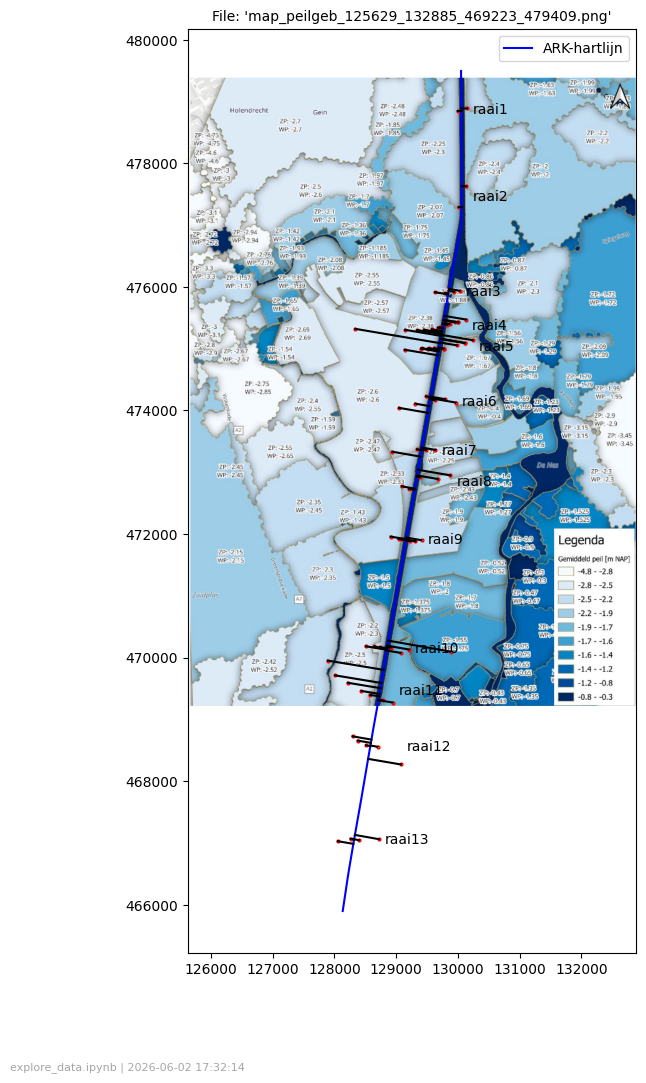

In [13]:

fig, ax = plt.subplots(figsize=(8,12))

im = 0

extent = list(map(float, re.findall(r'\d+', maps[im])))

img = Image.open(os.path.join(dirs.pb_imag, maps[im]))
ax.imshow(img, extent=extent, origin='upper')

pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')

pbxy.plot(ax, mec='r', mfc='none', ms=2)
pbxy.put_raai_names(ax, ha='left', va='center')
ax.plot(hartlijn_ARK[:,0], hartlijn_ARK[:,1], 'b', label='ARK-hartlijn')
ax.set_aspect(1)

ax.set_title(f"File: '{maps[im]}'", fontsize=10)
ax.legend()

for pb in pbxy.data.index:
    rec = pbxy.data.loc[pb]
    ax.plot([rec['x'], rec['xhit']], [rec['y'], rec['yhit']], 'k')
    


logo(fig, NOTEBOOK_NAME)
if im == 0:
    fig.savefig(os.path.join(dirs.images, "peilgeb_pb"))
if im == 2:
    fig.savefig(os.path.join(dirs.images, "ligging_dsn_Deltares"))


# Grondwaterstanden

Verkregen webplotdigitizer vanaf de figuren in Deltares rapport "Systeemanalyze, concept maart 2026".

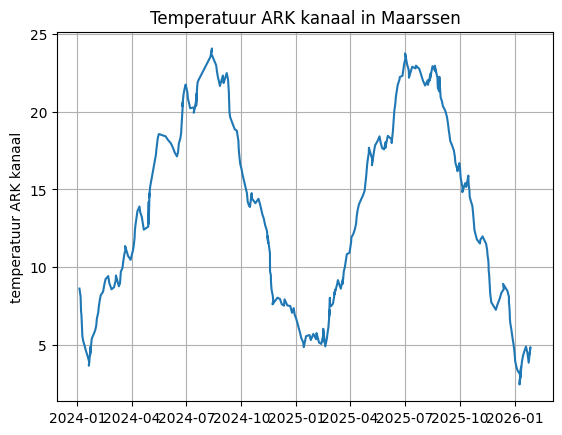

In [63]:
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'), index_col=0, parse_dates=True)
temp_ark.columns = ['temp']
temp_ark.index.name = 'datetime'
temp_ark

fig, ax = plt.subplots()
ax.plot(temp_ark.index, temp_ark['temp'])
ax.set_ylabel("temperatuur ARK kanaal")
ax.set_title("Temperatuur ARK kanaal in Maarssen")
ax.grid()


# Plot heads en temperatures of all rows (as far as as data is available)

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a,

Month-averaged head around the 3 dates given min, max and min values
pb1,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.322
pb2,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.376
pb3,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.144
pb4,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.403
pb5,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.382
pb6,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.502
pb7,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.489
pb8,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.565
pb9,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.481
pb10,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.559
pb101,2025-01-25,2025-08-01,2026-02-01,nan,-1.692,-1.78
pb102,2025-01-25,2025-08-01,2026-02-01,nan,-1.739,-1.841
pb201,2025-01-25,2025-08-01,2026-02-01,nan,-1.481,-1.684
pb202,2025-01-25,2025-08-01,2026-02-01,nan,-1.49,-1.7
pb301,2025-01-25,2025-08-01,2026-02-01,nan,nan,-1.654
pb302,2025-01-25,2025-08-01,2026-02-01,nan,-1.235,-1.556
pb303,2025-01-25,2025-08-01,2026-02-01,nan,-1.116,nan
pb304,2025-01-25,2025

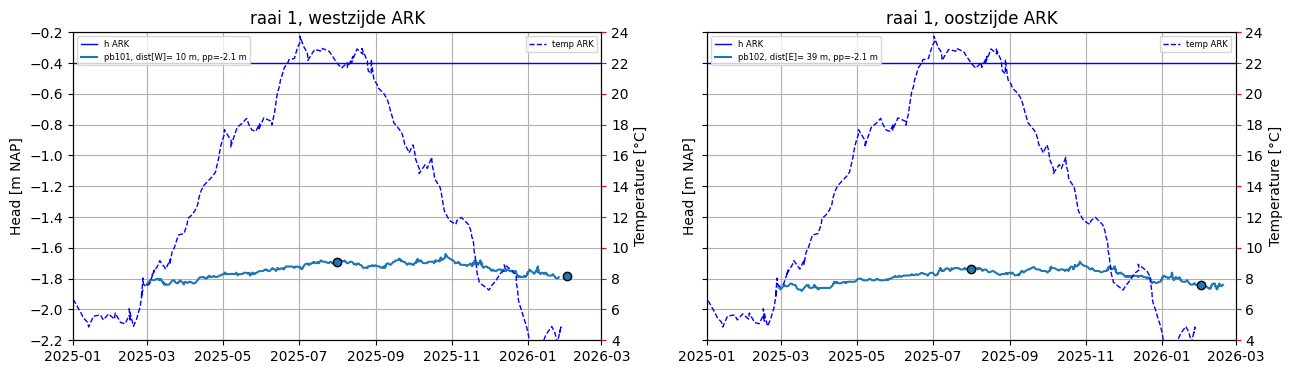

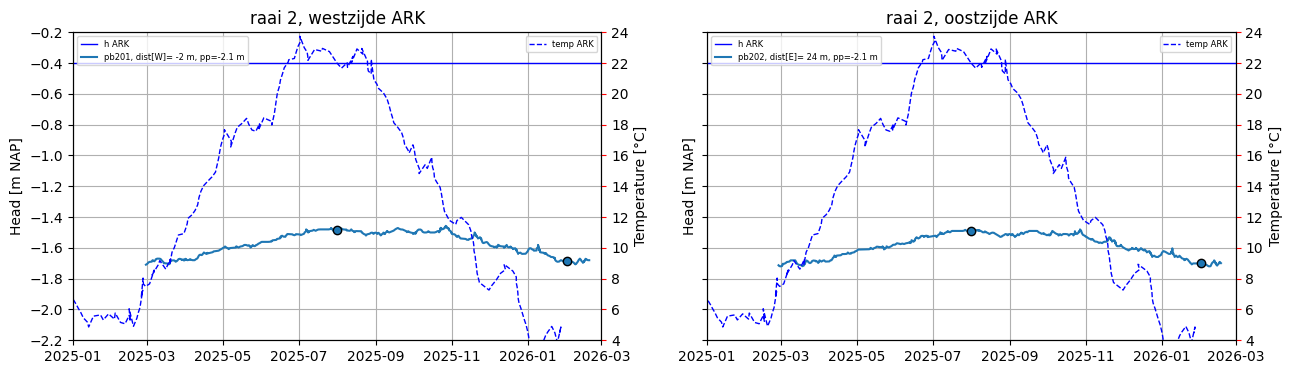

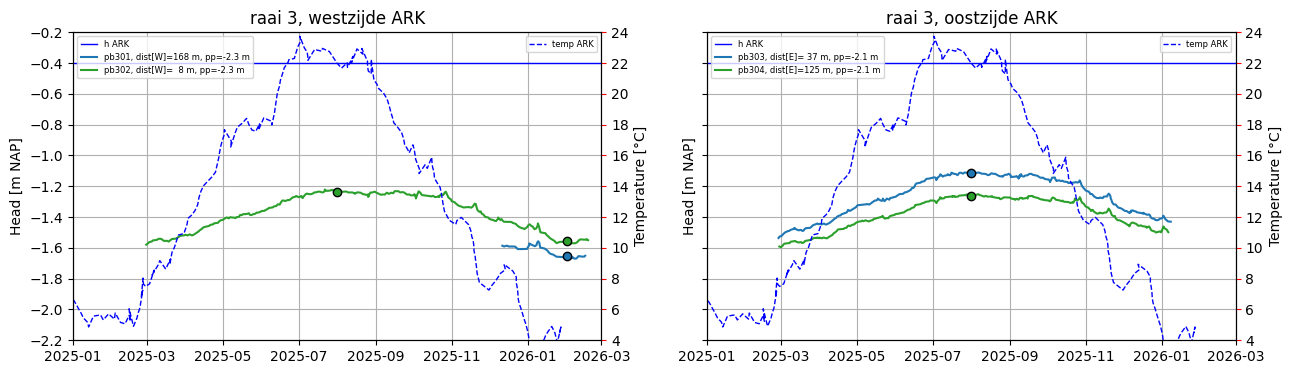

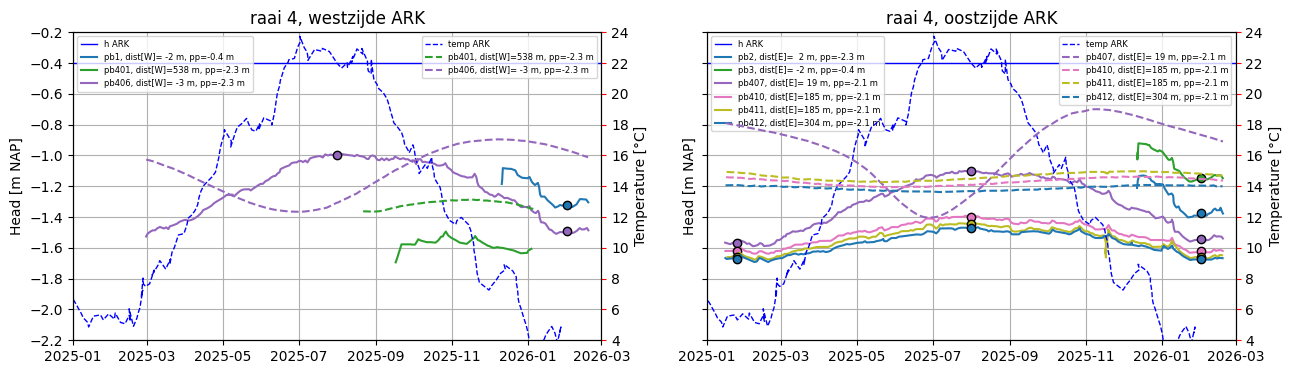

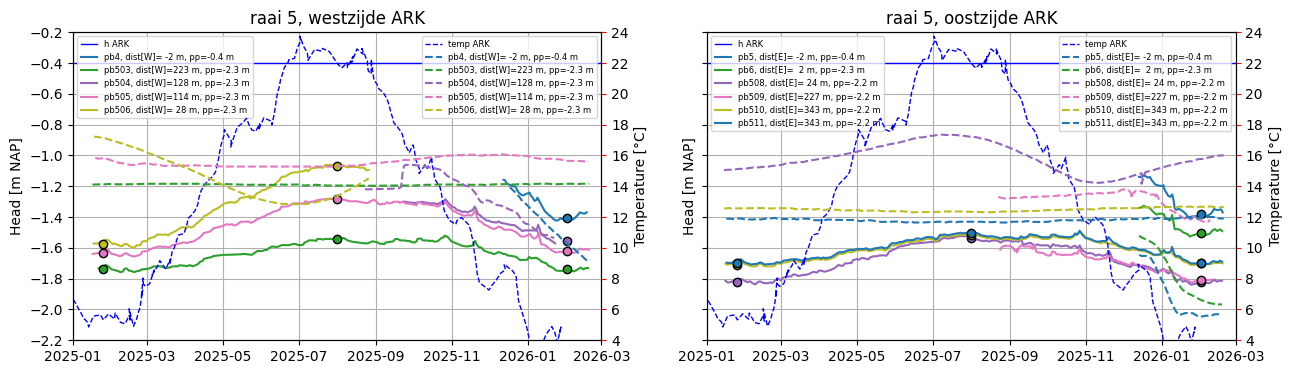

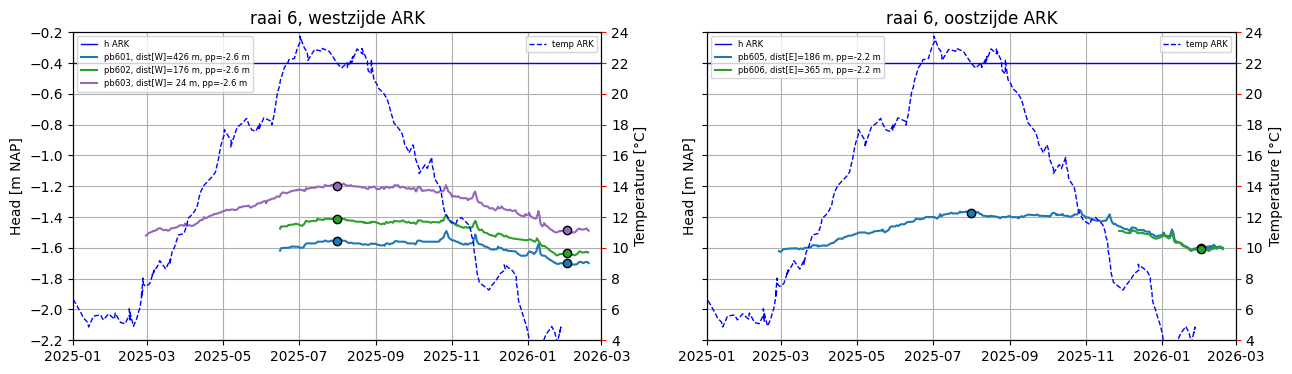

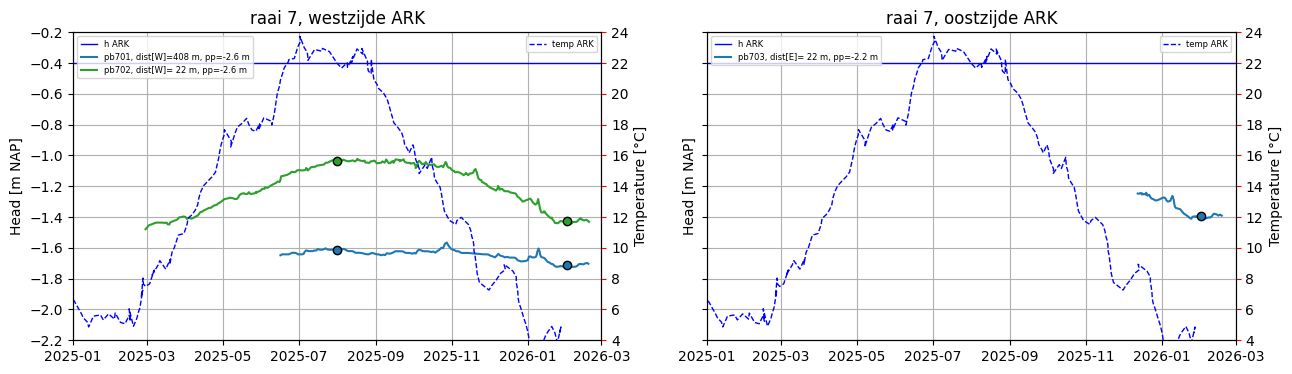

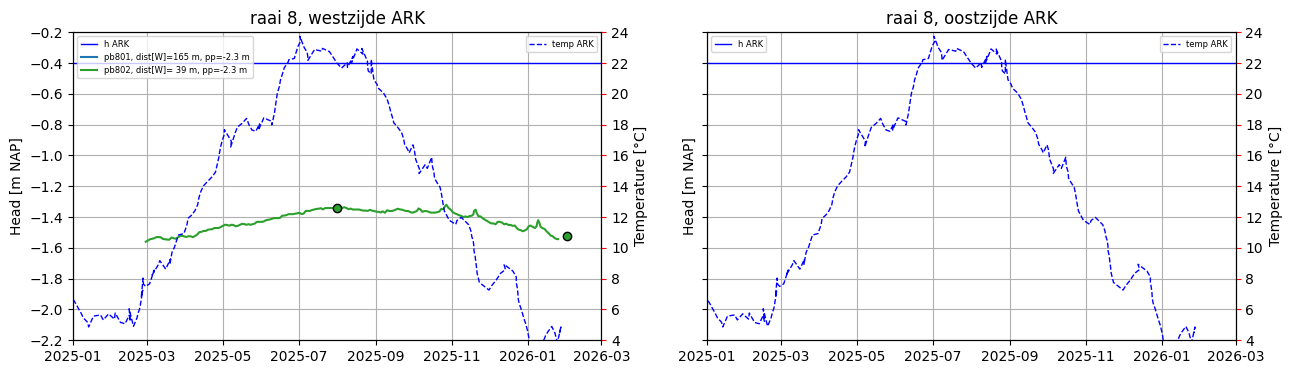

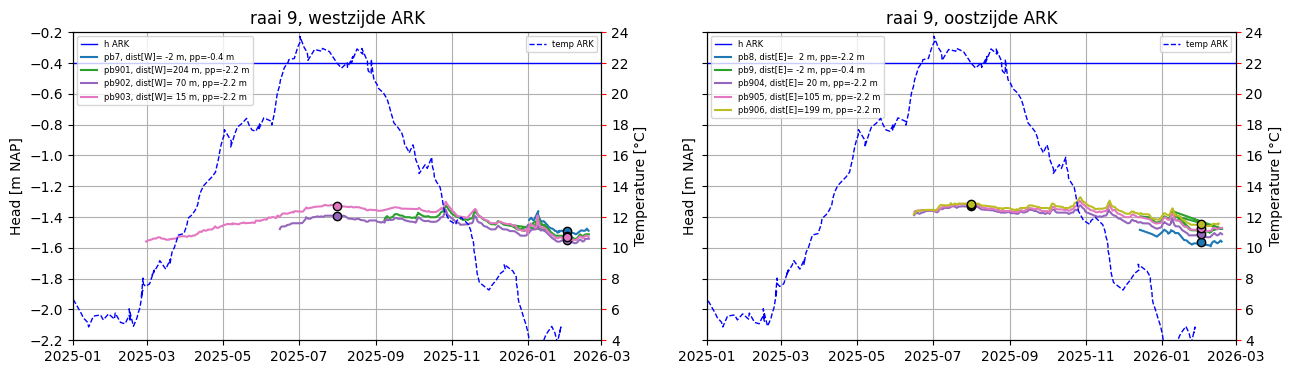

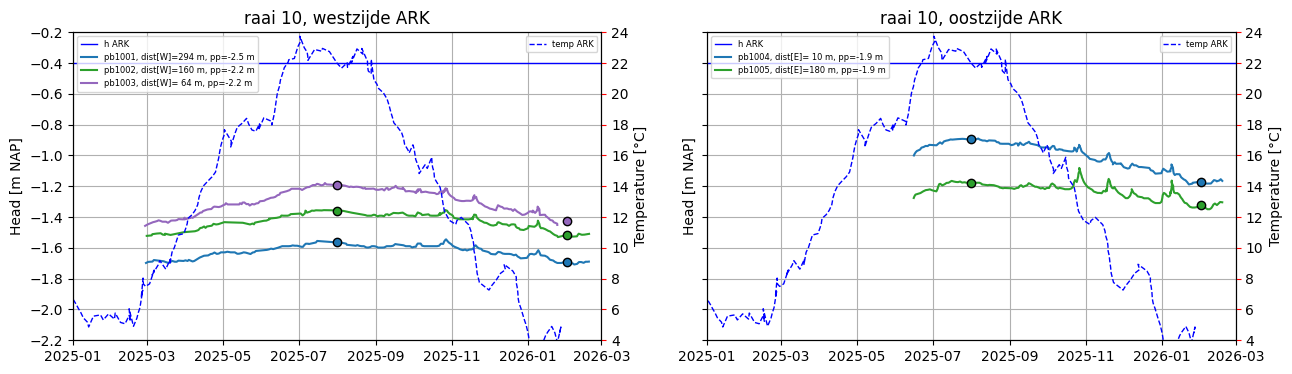

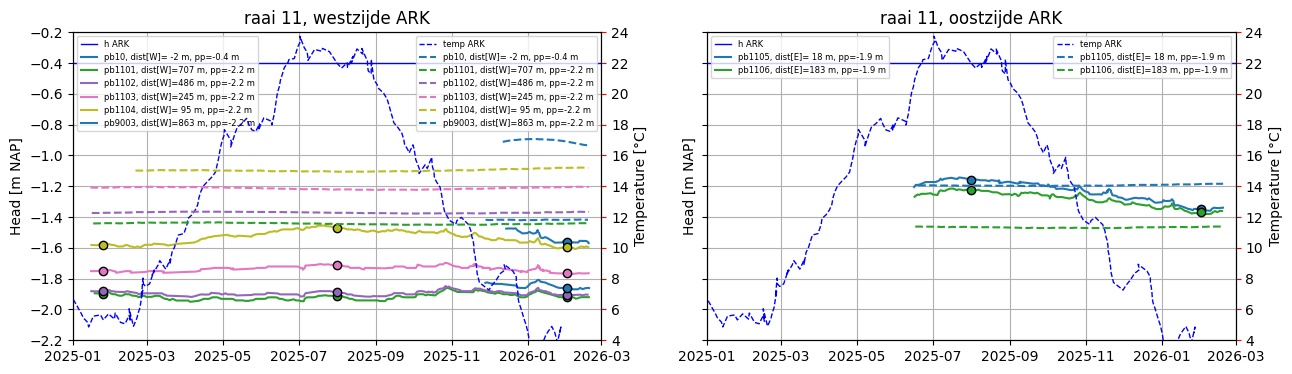

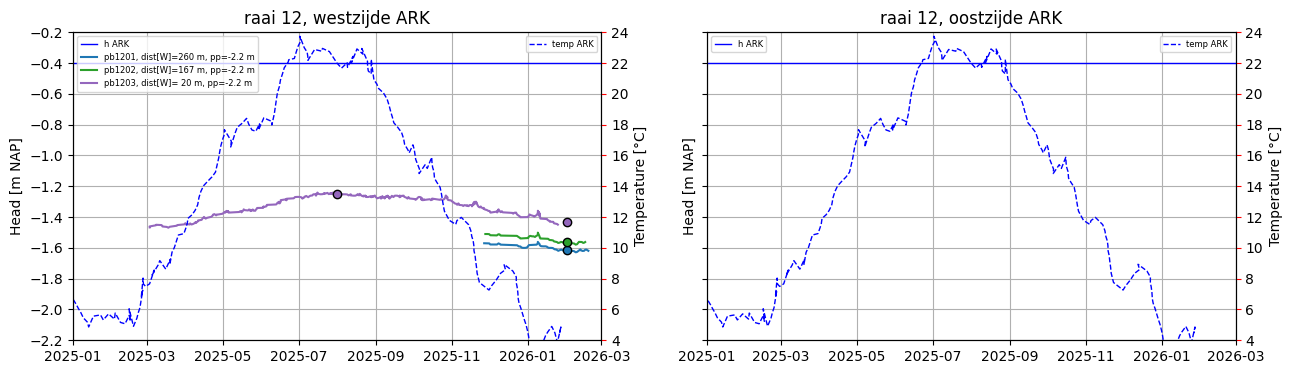

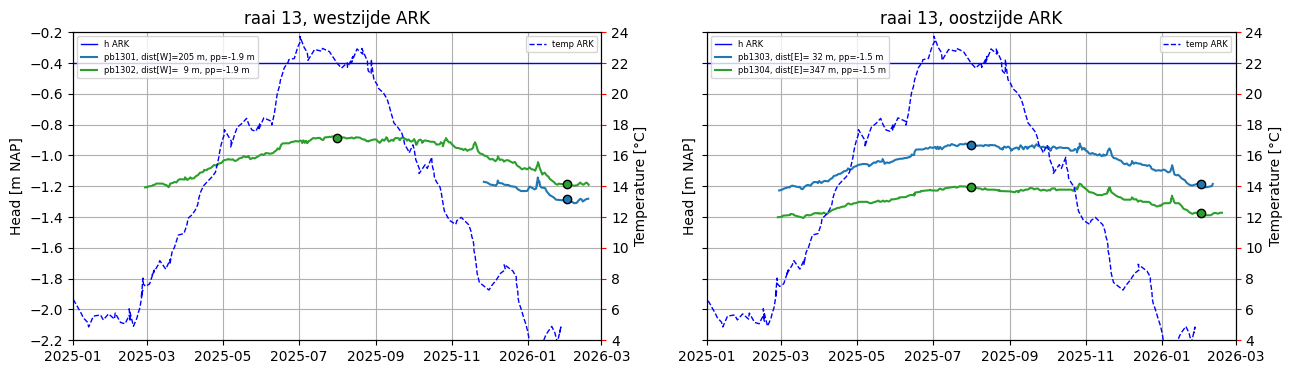

In [98]:
pbxy = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pbkan = Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbKanaal')

# --- pd.DataFrame
pb_tauw_meta   = pbxy.data
pb_kanaal_meta = pbkan.data

b_ARK = 50

# --- Get ARK temperature
temp_ark = pd.read_csv(os.path.join(dirs.pb_data, 'tempARK_maarssen.csv'),
                       index_col=0, parse_dates=True)
temp_ark.columns=['temp']
temp_ark.index.name = 'datetime'


# --- Get dictionary with one fig for every row with 2 head and 2 overlapping temp axes
figaxs = {}
for raai in range(1, 14):
    fig, (axW, axE) = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True)
    
    # logo(fig, NOTEBOOK_NAME)
    
    axW.set_title(f"raai {raai}, westzijde ARK")
    axE.set_title(f"raai {raai}, oostzijde ARK")
        
    xlim = (np.datetime64("2025-01-01"), np.datetime64("2026-03-01"))            
    axW.set_xlim(xlim)
    axE.set_xlim(xlim)
    
    ticks_h    = np.linspace(-2.2, -0.2, 11)
    ticks_temp = np.linspace(4, 24, 11)
    lim_h    = ticks_h[[0, -1]]
    lim_temp = ticks_temp[[0, -1]]
    
    axW.set_ylim(lim_h)
    axE.set_ylim(lim_h)
 
    axWT = axW.twinx()
    axET = axE.twinx()
    
    axET.set_ylabel("temp")
        
    axWT.set_ylim(lim_temp)
    axET.set_ylim(lim_temp)

    axW.set_yticks(ticks_h)
    axE.set_yticks(ticks_h)
    
    axWT.set_yticks(ticks_temp)
    axET.set_yticks(ticks_temp)
    
    axW.grid(True)
    axE.grid(True)
    
    axWT.tick_params(axis='y', color='red')
    axET.tick_params(axis='y', color='red')
    
    axW.set_ylabel('Head [m NAP]')
    axE.set_ylabel('Head [m NAP]')
    axWT.set_ylabel('Temperature [°C]')
    axET.set_ylabel('Temperature [°C]')
    
    hARK = -0.4
    axW.plot(xlim, [hARK, hARK], '-', color='blue', lw=1, label="h ARK") 
    axE.plot(xlim, [hARK, hARK], '-', color='blue', lw=1, label="h ARK")
    axWT.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')
    axET.plot(temp_ark.index, temp_ark.loc[:, 'temp'], '--', color='blue', lw=1, label='temp ARK')

    figaxs[raai] = {'fig': fig, "axW":axW, "axE":axE, "axWT":axWT, "axET":axET}
    
Y = {}

# ---- Get data from these files, determine its row and plot head and temperature on the correct row head and temp axes
for fbn in [ 'pb[0-9].csv', 'pb10.csv', 'pb1[0-9][0-9].csv', 'pb2[0-9][0-9].csv', 'pb3[0-9][0-9].csv', 'pb4[0-9][0-9].csv',
            'pb5[0-9][0-9].csv', 'pb6[0-9][0-9].csv', 'pb7[0-9][0-9].csv', 'pb8[0-9][0-9].csv',
            'pb9[0-9][0-9].csv', 'pb10[0-9][0-9].csv', 'pb11[0-9][0-9].csv',
            'pb12[0-9][0-9].csv', 'pb13[0-9][0-9].csv', 'pb900[0-9].csv']:
    
    # --- current list of csv data files
    pb_csv_files = sorted(glob(os.path.join(dirs.pb_data, fbn)))

    # --- for each piezometer data csv file
    for fname in pb_csv_files:
        basename = os.path.basename(fname)        
        pb_idx = int(re.findall(r"(\d+)", basename)[0])
        try:
            # --- Normal drilled piezometer
            rec = pb_tauw_meta.loc[pb_idx]
        except Exception:
            # --- Then a sounding piezometer (not drilled) in or next to the ARK
            rec = pb_kanaal_meta.loc[pb_idx]
          
        # --- Specifics for this piezometer  
        raai = rec['raai']
        dist = rec['dist'] - b_ARK
        WE   = rec['WE']
        VP   = (rec['ZP'] + rec['WP']) / 2
                
        # --- knowing the row of this piezometer, get the correct figure and axes
        fig, axW, axE, axWT, axET = (figaxs[raai]['fig'],
                                     figaxs[raai]['axW'], figaxs[raai]['axE'],
                                     figaxs[raai]['axWT'], figaxs[raai]['axET'])
        
        # --- get the head data
        pb = pd.read_csv(fname, header=None, parse_dates=True, index_col=0)
        pb.columns=['h']
        pb.index.name = 'datetime'
        
        t = pb.index
        y = pb.loc[:, 'h'].values
        
        # --- we want the min and max (average over 1 month around occuring dates)
        mask1 = np.logical_and(t>np.datetime64("2025-01-01"), t < np.datetime64("2025-02-20"))
        mask2 = np.logical_and(t>np.datetime64("2025-07-15"), t < np.datetime64("2025-08-15"))
        mask3 = np.logical_and(t>np.datetime64("2026-01-15"), t < np.datetime64("2026-03-01"))
        
        # --- Get these special values
        y1 = np.round(np.median(y[mask1]), 3)
        y2 = np.round(np.median(y[mask2]), 3)
        y3 = np.round(np.median(y[mask3]), 3)
        # print(f"{basename[:-4]:6} {raai} {y1}, {y2}, {y3}")
        
        # --- Store these data in dict
        tt = [np.datetime64("2025-01-25"), np.datetime64("2025-08-01"), np.datetime64("2026-02-01")]
        Y[basename[:-4]] ={'t':tt, 'h':[y1, y2, y3]}
        
        # --- Is this piezometer located to the west or the east of the ARK canal?
        # --- Use correct axes
        if WE=='W':
            ax=axW
        else:
            ax=axE
        # --- plot time series
        ln, = ax.plot(t, y, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, pp={VP:.2} m")
        clr = ln.get_color()

        # --- special points
        ax.plot(tt, [y1, y2, y3], 'o', mfc=clr, mec='k')
        
        # --- Second part, add temperature
        # --- same name but "temp_" prepended
        fname_temp = os.path.join(dirs.pb_data, f'temp_pb{pb_idx}.csv')
        try:
            pb_temp = pd.read_csv(fname_temp, header=None, parse_dates=True, index_col=0)
            pb_temp.columns=['temp']
            pb_temp.index.name = 'datetime'
        except FileNotFoundError:
            # --- if the temp .csv file does not exist for this piezometer, skip it
            continue
        
        # --- Plot the temperature time series on the correct axes and with same color as the head
        t_temp = pb_temp.index
        y_temp = pb_temp.loc[:, 'temp'].values
        
        if WE=='W':
            ax=axWT
        else:
            ax=axET
        ax.plot(t_temp, y_temp, '--', color=clr, label=f"{basename[:-4]}, dist[{WE}]={dist:3.0f} m, pp={VP:.2} m")

# --- Finally set the legends for all axes
for raai, figax in figaxs.items():    
    figax['axW'].legend(loc='upper left', fontsize=6)
    figax['axE'].legend(loc='upper left', fontsize=6)
    figax['axWT'].legend(loc='upper right', fontsize=6)
    figax['axET'].legend(loc='upper right', fontsize=6)
    
    
print("Month-averaged head around the 3 dates given min, max and min values")
for fn, data in Y.items():
    print(f"{fn},{data['t'][0]},{data['t'][1]},{data['t'][2]},{data['h'][0]},{data['h'][1]},{data['h'][2]}")

In [ ]:
for raai, figax in figaxs.items():
    save_name = f"h_temp_raai{raai}.pdf"
    fig_path = os.path.join(dirs.images, save_name)    
    figax['fig'].savefig(fig_path)
    print(f"fig raai {raai} saved to: {fig_path}")
        
# pb, t, y

fig raai 1 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai1.pdf
fig raai 2 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai2.pdf
fig raai 3 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai3.pdf
fig raai 4 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai4.pdf
fig raai 5 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai5.pdf
fig raai 6 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai6.pdf
fig raai 7 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai7.pdf
fig raai 8 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai8.pdf
fig raai 9 saved to: /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/h_temp_raai9.pdf
fig raai 1

In [ ]:
# --- pd.DataFrame
pb_meta = pbxy.data
b_ARK = 50



for fbn in ['pb[0-9].csv', 'pb1[0-9][0-9].csv', 'pb2[0-9][0-9].csv', 'pb3[0-9][0-9].csv', 'pb4[0-9][0-9].csv',
            'pb5[0-9][0-9].csv', 'pb6[0-9][0-9].csv', 'pb7[0-9][0-9].csv', 'pb8[0-9][0-9].csv',
            'pb9[0-9][0-9].csv', 'pb10[0-9][0-9].csv', 'pb11[0-9][0-9].csv',
            'pb12[0-9][0-9].csv', 'pb13[0-9][0-9].csv']:
    
    pb_csv_files = sorted(glob(os.path.join(dirs.pb_data, fbn)))

    fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    sharex=True,
    sharey=True,
    figsize=(12, 5)
    )

    axsT = [a.twinx() for a in axs]
    
    axW, axE = axs
    axWT, axET = axsT
    
    colors = color_cycler()

    for fname in pb_csv_files:
        clr = next(colors)
        basename = os.path.basename(fname)        
        pb_idx = int(re.findall(r"(\d+)", basename)[0])
        try:
            rec = pb_meta.loc[pb_idx]
        except Exception:
            pass

        rec = pb_meta.loc[pb_idx]
        dist = rec['d'] - b_ARK
        WE   = rec['WE']
        VP   = (rec['ZP'] + rec['WP']) / 2
        
        pb = pd.read_csv(fname, header=None, parse_dates=True, index_col=0)
        pb.columns=['h']
        pb.index.name = 'datetime'

        t = pb.index
        y = pb.loc[:, 'h'].values
        if WE=='W':
            ax=axW
        else:
            ax=axE
        ax.plot(t, y, color=clr, label=f"{basename:6} d[{WE}]={dist:3.0f} m pp={VP:.2} m")

        try:
            temp = pd.read_csv(os.path.join(dirs.pb_data, 'temp_' + basename), header=None, parse_dates=True, index_col=0)
            temp.columns=['temp']
            temp.index.name = 'datetime'
            t_temp = temp.index
            y_temp = temp.loc[:, 'temp'].values
            
            if WE=='W':
                ax=axWT
            else:
                ax=axET
            ax.plot(t_temp, y_temp, color=clr, ls='--', label=f"{basename:6}")
        except FileNotFoundError:
            pass

    axW.set_ylim(-2.0, -0.8); axWT.set_ylim(5, 25)
    axE.set_ylim(-2.0, -0.8); axET.set_ylim(5, 25)
    
    axW.grid()
    axE.grid()
    
    axW.legend(loc='upper left', fontsize=8)
    axE.legend(loc='upper left', fontsize=8)
    axWT.legend(loc='upper right', fontsize=8)
    axET.legend(loc='upper right', fontsize=8)
